# Polymer — methylation → drug response, with the genes that drive it

**The product, in one notebook.** Given a tumor/cell-line **methylome**, Polymer:
1. predicts the **response (AUC) to every drug** and ranks them, and
2. explains *why* — the **genes of interest that are hyper- or hypo-methylated** in this
   sample and push the predicted response up or down.

A single methylation **encoder** is pretrained across **all drugs**; each drug is a learned
embedding, so `predicted AUC = drug_bias + ⟨encoder(methylome), drug_embedding⟩`
(lower AUC = more sensitive). Prediction uses the **gene-level** matrix (the strongest signal
in our benchmarks); the **promoter** matrix is shown alongside as focal hyper/hypo annotation.

**What to watch in this notebook**
- Stage 2: live **training curves** (train vs val) and **test fit** vs the per-drug baseline.
- Stage 3: a held-out patient's **ranked drug list** with predicted AUCs.
- Stage 4: that patient's **hyper/hypo-methylated genes**.
- Stage 5: **why this drug** — gradient attribution × methylation deviation = the driver genes.

> Honest framing: trained on GDSC **cell lines**, not patients; gene-level betas average over
> promoter CpGs. This is a methodology demo on open data, not a clinical device.

In [ ]:
import os
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".mplcache"))
import numpy as np, pandas as pd
import torch, torch.nn as nn
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

from strata.data import gdsc

SEED = 1337
N_GENES = 3000      # top-variance gene-level features
EMB, HID = 32, 256
EPOCHS, BATCH, LR = 30, 4096, 2e-3
VAL_FRAC = TEST_FRAC = 0.15
torch.manual_seed(SEED); np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 110
print("Polymer demo — torch", torch.__version__)

## Stage 1 — Load methylation + drug response, build a cell-line-blind split

Gene-level methylation (the predictor), promoter methylation (for hyper/hypo annotation),
and GDSC2 drug AUCs. We split on **cell lines** so every test patient is unseen.

In [ ]:
gene = gdsc.load_gdsc_methylation_genelevel(); gene.index = gene.index.astype(str)
prom = gdsc.load_gdsc_methylation_promoter();  prom.index = prom.index.astype(str)
drug = gdsc.load_gdsc_drug_response()
anno = gdsc.load_gdsc_annotations()

# drug metadata (target / pathway) for nicer labels
try:
    meta = (pd.read_csv("gdsc2_merged.csv", usecols=["DRUG_NAME", "PUTATIVE_TARGET", "PATHWAY_NAME"])
            .groupby("DRUG_NAME").first())
except Exception:
    meta = pd.DataFrame(columns=["PUTATIVE_TARGET", "PATHWAY_NAME"])

lines = gene.index.to_numpy()
line_pos = {c: i for i, c in enumerate(lines)}
d = drug[drug["COSMIC_ID"].astype(str).isin(set(lines))].dropna(subset=["auc"]).copy()
d["COSMIC_ID"] = d["COSMIC_ID"].astype(str)
d = d.groupby(["COSMIC_ID", "drug_name"], as_index=False)["auc"].mean()
drug_names = sorted(d["drug_name"].unique())
drug_pos = {dn: i for i, dn in enumerate(drug_names)}
n_lines, n_drugs = len(lines), len(drug_names)

li = d["COSMIC_ID"].map(line_pos).to_numpy()
di = d["drug_name"].map(drug_pos).to_numpy()
y = d["auc"].to_numpy(float)

rng = np.random.default_rng(SEED)
order = rng.permutation(n_lines)
n_te, n_va = int(n_lines * TEST_FRAC), int(n_lines * VAL_FRAC)
test_l, val_l = set(order[:n_te]), set(order[n_te:n_te + n_va])
tr = ~np.isin(li, list(test_l | val_l)); va = np.isin(li, list(val_l)); te = np.isin(li, list(test_l))
train_line_mask = ~np.isin(np.arange(n_lines), list(test_l | val_l))
print(f"{n_lines} lines | {n_drugs} drugs | {len(y):,} (line,drug) pairs")
print(f"split: train={train_line_mask.sum()} lines | val={len(val_l)} | test={len(test_l)}")
print(f"gene-level: {gene.shape} | promoter: {prom.shape}")

## Stage 2 — Train the encoder across all drugs (watch the training)

Top-variance genes are selected on **train lines only** and z-scored with train stats (no leakage).
We capture train/val loss every epoch and plot the curves, then check the fit on held-out lines.

epoch  0  train MSE=0.949  val RMSE(std)=0.823
epoch  5  train MSE=0.294  val RMSE(std)=0.550
epoch 10  train MSE=0.251  val RMSE(std)=0.529
epoch 15  train MSE=0.228  val RMSE(std)=0.524
epoch 20  train MSE=0.215  val RMSE(std)=0.509
epoch 25  train MSE=0.207  val RMSE(std)=0.512
epoch 29  train MSE=0.200  val RMSE(std)=0.514


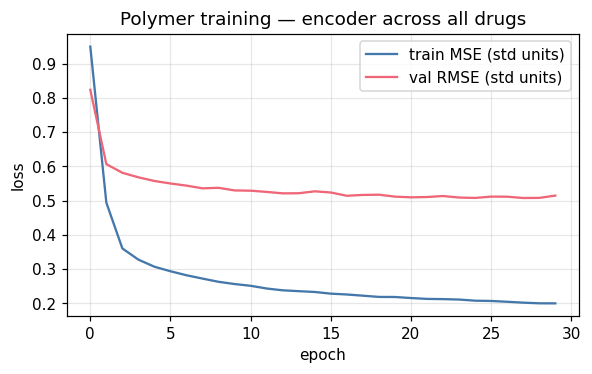

In [3]:
# features: top-variance genes (train-selected), z-scored on train
Mfull = gene.to_numpy(np.float32)
var = Mfull[train_line_mask].var(0)
panel = np.argsort(var)[::-1][:N_GENES]
panel_genes = [str(gene.columns[j]) for j in panel]
X = Mfull[:, panel]
mu = X[train_line_mask].mean(0); sd = X[train_line_mask].std(0); sd[sd == 0] = 1.0
Xz = torch.tensor((X - mu) / sd)
ymu, ysd = y[tr].mean(), y[tr].std() + 1e-8
yz = torch.tensor((y - ymu) / ysd, dtype=torch.float32)
li_t, di_t = torch.tensor(li), torch.tensor(di)

class Polymer(nn.Module):
    def __init__(self, n_feat, n_drugs):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_feat, HID), nn.ReLU(), nn.BatchNorm1d(HID), nn.Dropout(0.3),
            nn.Linear(HID, EMB))
        self.drug_emb = nn.Embedding(n_drugs, EMB)
        self.drug_bias = nn.Embedding(n_drugs, 1)
        nn.init.normal_(self.drug_emb.weight, std=0.1); nn.init.zeros_(self.drug_bias.weight)
    def forward(self, li, di):
        ce = self.encoder(Xz[li])
        return self.drug_bias(di).squeeze(1) + (ce * self.drug_emb(di)).sum(1)

net = Polymer(N_GENES, n_drugs)
opt = torch.optim.Adam(net.parameters(), lr=LR, weight_decay=1e-5)
loss_fn = nn.MSELoss()
tr_idx = np.where(tr)[0]

@torch.no_grad()
def predict(mask_idx):
    net.eval()
    return net(li_t[mask_idx], di_t[mask_idx]).numpy() * ysd + ymu

tr_curve, va_curve = [], []
va_idx, te_idx = np.where(va)[0], np.where(te)[0]
for ep in range(EPOCHS):
    net.train(); perm = tr_idx[rng.permutation(len(tr_idx))]
    ep_loss = []
    for s in range(0, len(perm), BATCH):
        b = torch.tensor(perm[s:s+BATCH]); opt.zero_grad()
        loss = loss_fn(net(li_t[b], di_t[b]), yz[b]); loss.backward(); opt.step()
        ep_loss.append(loss.item())
    tr_curve.append(np.mean(ep_loss))
    vp = predict(va_idx); va_curve.append(np.sqrt(np.mean((y[va]-vp)**2)) / ysd)  # std units
    if ep % 5 == 0 or ep == EPOCHS-1:
        print(f"epoch {ep:2d}  train MSE={tr_curve[-1]:.3f}  val RMSE(std)={va_curve[-1]:.3f}")

plt.figure(figsize=(6,3.4))
plt.plot(tr_curve, label="train MSE (std units)", color="#4477aa")
plt.plot(va_curve, label="val RMSE (std units)", color="#ee6677")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Polymer training — encoder across all drugs"); plt.show()

per-drug baseline   RMSE=0.0943  r=0.757
Polymer             RMSE=0.0746  r=0.857  (+20.9% RMSE)
personalized within-line rho (de-meaned) = +0.489


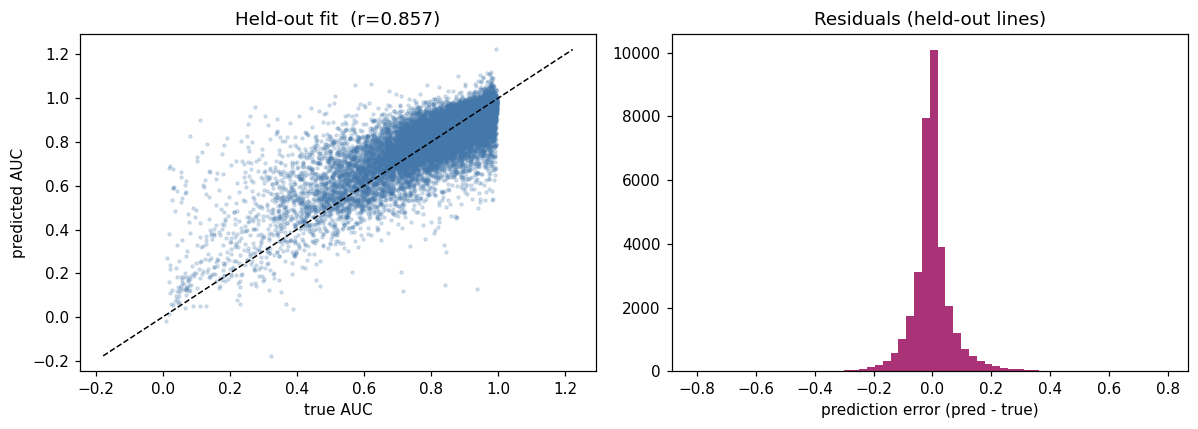

In [4]:
# held-out fit vs the per-drug-mean baseline
test_pred = predict(te_idx)
drug_mean_tr = pd.Series(y[tr]).groupby(pd.Series(di[tr])).mean()
glob = y[tr].mean()
base = np.array([drug_mean_tr.get(dd, glob) for dd in di[te]])

def rmse_r(yt, p): return np.sqrt(np.mean((yt-p)**2)), pearsonr(yt, p)[0]
b_rmse, b_r = rmse_r(y[te], base)
m_rmse, m_r = rmse_r(y[te], test_pred)
# personalization (de-meaned within-line)
dm_te = base
rhos = []
for L in test_l:
    mk = li[te_idx] == L
    if mk.sum() >= 10 and np.ptp(test_pred[mk]-dm_te[mk]) and np.ptp(y[te][mk]-dm_te[mk]):
        rhos.append(spearmanr(test_pred[mk]-dm_te[mk], y[te][mk]-dm_te[mk]).correlation)
print(f"per-drug baseline   RMSE={b_rmse:.4f}  r={b_r:.3f}")
print(f"Polymer             RMSE={m_rmse:.4f}  r={m_r:.3f}  ({(b_rmse-m_rmse)/b_rmse*100:+.1f}% RMSE)")
print(f"personalized within-line rho (de-meaned) = {np.nanmean(rhos):+.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(y[te], test_pred, s=4, alpha=0.2, color="#4477aa")
lims = [min(y[te].min(), test_pred.min()), max(y[te].max(), test_pred.max())]
ax[0].plot(lims, lims, 'k--', lw=1); ax[0].set_xlabel("true AUC"); ax[0].set_ylabel("predicted AUC")
ax[0].set_title(f"Held-out fit  (r={m_r:.3f})")
ax[1].hist(test_pred - y[te], bins=60, color="#aa3377")
ax[1].set_xlabel("prediction error (pred - true)"); ax[1].set_title("Residuals (held-out lines)")
plt.tight_layout(); plt.show()

## Stage 3 — Predicted response for a held-out patient

Pick a held-out cell line (a stand-in "patient"), score **all 286 drugs** from its methylome,
and rank by predicted AUC (lower = more sensitive).

PATIENT: line 753608  (Non-Small Cell Lung Carcinoma)
Top 10 predicted-sensitive drugs:

                drug pred_auc vs_avg                          target
Sepantronium bromide    0.190 -0.007                           BIRC5
       Staurosporine    0.331 -0.071 Broad spectrum kinase inhibitor
           CDK9_5038    0.485 -0.016                            CDK9
        Dactinomycin    0.487 -0.106                  RNA polymerase
         Gemcitabine    0.538 -0.110       Pyrimidine antimetabolite
          Dinaciclib    0.539 -0.039          CDK1, CDK2, CDK5, CDK9
               SN-38    0.561 -0.199                            TOP1
           CDK9_5576    0.586 -0.004                            CDK9
              MG-132    0.592 +0.066               Proteasome, CAPN1
          Epirubicin    0.595 -0.104                   Anthracycline


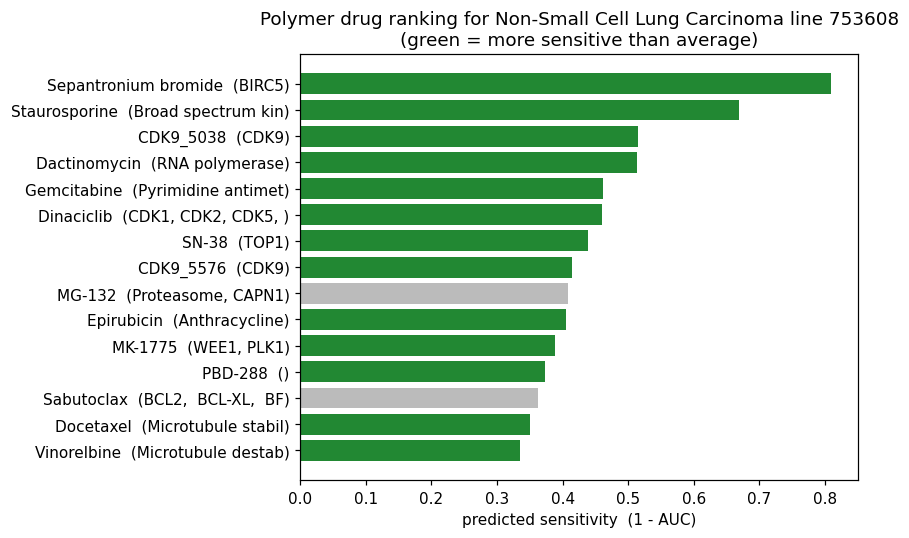

In [5]:
# choose the held-out line with the most measured drugs (good ground-truth coverage)
cand = sorted(test_l, key=lambda L: -(li[te_idx] == L).sum())
PATIENT = cand[0]
cid = lines[PATIENT]
ctype = anno.reindex([cid])["cancer_type"].iloc[0] if cid in anno.index else "Unknown"

@torch.no_grad()
def score_all_drugs(line_idx):
    net.eval()
    ce = net.encoder(Xz[line_idx:line_idx+1])                 # (1, EMB)
    s = net.drug_bias.weight.squeeze(1) + (ce * net.drug_emb.weight).sum(1)
    return s.numpy() * ysd + ymu                              # predicted AUC per drug

pred_auc = score_all_drugs(PATIENT)
rank = pd.DataFrame({
    "drug": drug_names,
    "pred_auc": pred_auc,
    "avg_auc": [drug_mean_tr.get(i, glob) for i in range(n_drugs)],
})
rank["vs_avg"] = rank["pred_auc"] - rank["avg_auc"]
rank["target"] = rank["drug"].map(lambda d: meta["PUTATIVE_TARGET"].get(d, "") if d in meta.index else "")
rank = rank.sort_values("pred_auc").reset_index(drop=True)

print(f"PATIENT: line {cid}  ({ctype})\nTop 10 predicted-sensitive drugs:\n")
print(rank.head(10)[["drug","pred_auc","vs_avg","target"]].to_string(
    index=False, formatters={"pred_auc":"{:.3f}".format, "vs_avg":"{:+.3f}".format}))

top = rank.head(15).iloc[::-1]
colors = ["#228833" if v < 0 else "#bbbbbb" for v in top["vs_avg"]]
plt.figure(figsize=(8, 5))
plt.barh(top["drug"] + "  (" + top["target"].fillna("").str.slice(0,18) + ")", 1 - top["pred_auc"], color=colors)
plt.xlabel("predicted sensitivity  (1 - AUC)")
plt.title(f"Polymer drug ranking for {ctype} line {cid}\n(green = more sensitive than average)")
plt.tight_layout(); plt.show()

## Stage 4 — Genes of interest: which are hyper/hypo-methylated in this patient?

For each panel gene we already have the cohort (train) mean/SD, so the patient's **z-score**
(its standardized input) directly says how **hyper-** (z>0) or **hypo-** (z<0) methylated it is
versus the population. We also look up the **promoter** beta for the same genes (the focal view).

Most HYPER-methylated genes in line 753608 (vs cohort):
        gene     z  beta cohort_mean promoter_beta
         LIF 2.113 0.618       0.339           NaN
        BCAN 1.970 0.868       0.627           NaN
     CYP2A13 1.768 0.609       0.337           NaN
      MIR429 1.679 0.887       0.632           NaN
LOC100131726 1.619 0.943       0.704           NaN
        NRN1 1.612 0.585       0.363           NaN
     C2orf54 1.547 0.874       0.683           NaN
       HOXB5 1.540 0.671       0.477           NaN
      PCOLCE 1.530 0.857       0.659           NaN
      ZNF513 1.442 0.585       0.396           NaN
       AIM1L 1.437 0.907       0.688           NaN
        GJB4 1.435 0.840       0.651           NaN


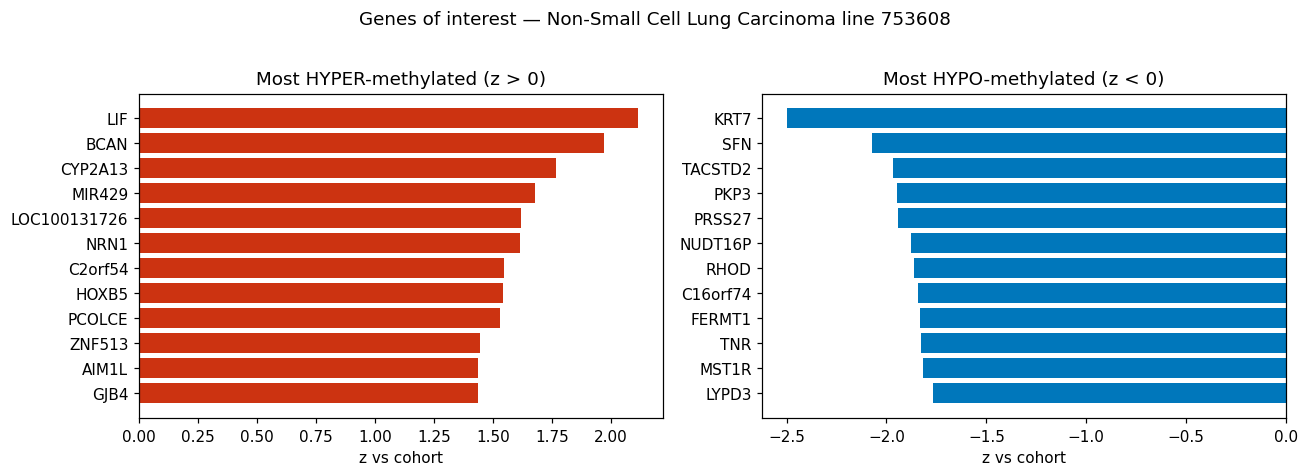

In [6]:
z = Xz[PATIENT].numpy()                          # standardized betas = hyper/hypo score
raw_beta = X[PATIENT]                            # patient's raw gene-level beta
prom_row = prom.loc[cid] if cid in prom.index else None

gene_status = pd.DataFrame({
    "gene": panel_genes, "z": z, "beta": raw_beta,
    "cohort_mean": mu,
})
gene_status["promoter_beta"] = [float(prom_row[g]) if (prom_row is not None and g in prom_row.index
                                                       and np.isfinite(prom_row[g])) else np.nan
                                for g in panel_genes]

hyper = gene_status.sort_values("z", ascending=False).head(12)
hypo  = gene_status.sort_values("z").head(12)
print(f"Most HYPER-methylated genes in line {cid} (vs cohort):")
print(hyper[["gene","z","beta","cohort_mean","promoter_beta"]].to_string(
    index=False, formatters={c:"{:.3f}".format for c in ["z","beta","cohort_mean","promoter_beta"]}))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].barh(hyper["gene"][::-1], hyper["z"][::-1], color="#cc3311")
ax[0].set_title("Most HYPER-methylated (z > 0)"); ax[0].set_xlabel("z vs cohort")
ax[1].barh(hypo["gene"][::-1], hypo["z"][::-1], color="#0077bb")
ax[1].set_title("Most HYPO-methylated (z < 0)"); ax[1].set_xlabel("z vs cohort")
fig.suptitle(f"Genes of interest — {ctype} line {cid}", y=1.02)
plt.tight_layout(); plt.show()

## Stage 5 — Why this drug? Driver genes = attribution × methylation deviation

For the top-recommended drug we take the **gradient** of its predicted AUC with respect to the
input methylation, and multiply by the patient's deviation (its z). That product is each gene's
**first-order contribution** to the predicted response. Negative = the gene's (hyper/hypo)methylation
**drives sensitivity**; positive = drives resistance. This is the "genes of interest" view tied
directly to the prediction.

WHY SN-38 for line 753608 (Non-Small Cell Lung Carcinoma) — predicted AUC 0.190
target/pathway: TOP1 / DNA replication

Top genes DRIVING SENSITIVITY (their hyper/hypo-methylation lowers predicted AUC):
    gene methylation      z contribution promoter_beta
 ARPP-21        hypo -1.644       -0.095           NaN
  RNF135        hypo -1.475       -0.092           NaN
   TEKT3        hypo -1.017       -0.084           NaN
  CHRNB1        hypo -1.355       -0.070           NaN
C1orf190       hyper  1.041       -0.068           NaN
FLJ11235        hypo -0.794       -0.066           NaN
 NUDT16P        hypo -1.876       -0.061           NaN
   DNAH3        hypo -1.367       -0.058           NaN
  MIR429       hyper  1.679       -0.056           NaN
   TTC22        hypo -1.646       -0.056           NaN
   WFDC2        hypo -1.633       -0.055           NaN
   MST1R        hypo -1.816       -0.054           NaN


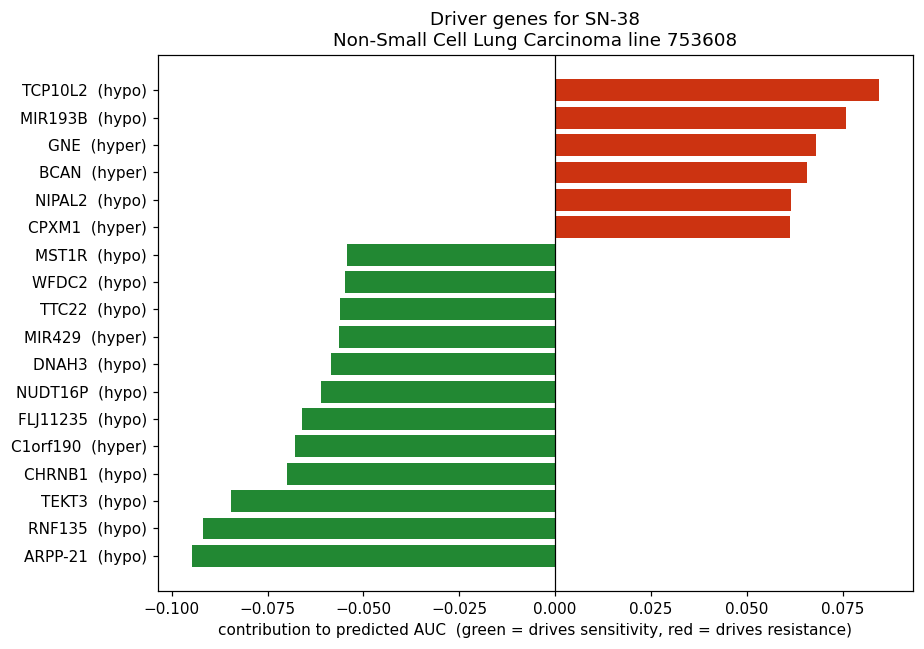

In [7]:
# Showcase the most PERSONALIZED pick: among the top-25 predicted-sensitive drugs,
# the one most below its population average (largest negative vs_avg). Override freely.
TARGET_DRUG = rank.head(25).sort_values("vs_avg").iloc[0]["drug"]
d_idx = drug_pos[TARGET_DRUG]

net.eval()
x = Xz[PATIENT].clone().detach().requires_grad_(True)
ce = net.encoder(x.unsqueeze(0))
score_std = net.drug_bias.weight[d_idx] + (ce * net.drug_emb.weight[d_idx]).sum()
score_std.backward()
grad = x.grad.numpy()                            # d(pred_std_AUC)/d(z_gene)
contrib = grad * x.detach().numpy()              # per-gene contribution to predicted AUC

drivers = pd.DataFrame({
    "gene": panel_genes, "contribution": contrib, "z": z,
    "promoter_beta": gene_status["promoter_beta"].values,
})
drivers["methylation"] = np.where(drivers["z"] > 0, "hyper", "hypo")
# most sensitivity-driving (most negative contribution = lowers predicted AUC)
sens = drivers.sort_values("contribution").head(12)
res = drivers.sort_values("contribution", ascending=False).head(6)

print(f"WHY {TARGET_DRUG} for line {cid} ({ctype}) — predicted AUC {rank.iloc[0]['pred_auc']:.3f}")
print(f"target/pathway: {meta['PUTATIVE_TARGET'].get(TARGET_DRUG,'?') if TARGET_DRUG in meta.index else '?'}"
      f" / {meta['PATHWAY_NAME'].get(TARGET_DRUG,'?') if TARGET_DRUG in meta.index else '?'}\n")
print("Top genes DRIVING SENSITIVITY (their hyper/hypo-methylation lowers predicted AUC):")
print(sens[["gene","methylation","z","contribution","promoter_beta"]].to_string(
    index=False, formatters={c:"{:.3f}".format for c in ["z","contribution","promoter_beta"]}))

top_drivers = pd.concat([sens, res]).sort_values("contribution")
colors = ["#228833" if c < 0 else "#cc3311" for c in top_drivers["contribution"]]
labels = [f"{g}  ({m})" for g, m in zip(top_drivers["gene"], top_drivers["methylation"])]
plt.figure(figsize=(8.5, 6))
plt.barh(labels, top_drivers["contribution"], color=colors)
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("contribution to predicted AUC  (green = drives sensitivity, red = drives resistance)")
plt.title(f"Driver genes for {TARGET_DRUG}\n{ctype} line {cid}")
plt.tight_layout(); plt.show()

## Demo script (what to say)

1. **Stage 2** — "We pretrain one methylation encoder across all 286 drugs. Here's the training
   curve; it generalizes to held-out patients, beating the per-drug-mean baseline (r shown)."
2. **Stage 3** — "Feed a new patient's methylome → Polymer ranks every drug. Green bars are drugs
   it thinks are *better for this patient than average* — that's personalization, not just potency."
3. **Stage 4** — "These are the genes hyper/hypo-methylated in this patient vs the population."
4. **Stage 5** — "And here's *why* the top drug was chosen: the specific (hyper/hypo)methylated genes
   driving the predicted sensitivity — an auditable, gene-level rationale."

**Caveats to own on stage:** GDSC cell lines (not patients); gene-level betas; attribution is
first-order (local). The method, not the clinical claim, is the product.

**Re-run knobs:** set `PATIENT = cand[k]` (Stage 3) for another patient; `TARGET_DRUG = "..."`
(Stage 5) to explain any drug; raise `EPOCHS` for a tighter fit.